<a href="https://colab.research.google.com/github/JobaAdewumi/nba_feture_engineering/blob/main/nba_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [10]:
df_original = pd.read_csv('nba-players.csv')

In [11]:
df_original.head()

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [12]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1340 non-null   int64  
 1   name         1340 non-null   object 
 2   gp           1340 non-null   int64  
 3   min          1340 non-null   float64
 4   pts          1340 non-null   float64
 5   fgm          1340 non-null   float64
 6   fga          1340 non-null   float64
 7   fg           1340 non-null   float64
 8   3p_made      1340 non-null   float64
 9   3pa          1340 non-null   float64
 10  3p           1340 non-null   float64
 11  ftm          1340 non-null   float64
 12  fta          1340 non-null   float64
 13  ft           1340 non-null   float64
 14  oreb         1340 non-null   float64
 15  dreb         1340 non-null   float64
 16  reb          1340 non-null   float64
 17  ast          1340 non-null   float64
 18  stl          1340 non-null   float64
 19  blk   

### Data Cleaning and Feature Engineering

We will now prepare the dataset for machine learning:
* **Drop non-predictive columns**: `name` and the index column `Unnamed: 0` do not contribute to performance prediction.
* **Feature Engineering**: We'll create `pts_per_min` to normalize scoring output by playing time.
* **Null Handling**: We'll check for and handle any missing values.

In [13]:
# Drop non-predictive columns
df_cleaned = df_original.drop(columns=['Unnamed: 0', 'name'])

# Feature Engineering: Points Per Minute
# Using a small epsilon to avoid division by zero if min is 0
df_cleaned['pts_per_min'] = df_cleaned['pts'] / (df_cleaned['min'] + 1e-5)

### Advanced Feature Engineering

To better predict a player's long-term success, we are adding metrics that measure efficiency rather than just volume:

1.  **True Shooting Percentage (TS%)**: Measures scoring efficiency by accounting for 2-pointers, 3-pointers, and free throws. Formula: $Points / (2 * (FGA + 0.44 * FTA))$.
2.  **Assist-to-Turnover Ratio**: A measure of ball security and playmaking IQ.
3.  **Defensive Impact Score**: A composite of steals and blocks normalized by minutes played.

**Feature Selection Rationale**:
*   **Volume vs. Efficiency**: Raw points are highly correlated with minutes played. TS% allows us to see who is scoring effectively regardless of usage.
*   **Redundancy Reduction**: While `fgm` and `fga` are highly correlated with `pts`, these new ratios provide unique signals about player quality that volume stats might mask.

In [14]:
# Engineering Advanced Metrics

# True Shooting Percentage (TS%)
# TS% = PTS / (2 * (FGA + 0.44 * FTA))
df_cleaned['ts_pct'] = df_cleaned['pts'] / (2 * (df_cleaned['fga'] + 0.44 * df_cleaned['fta']) + 1e-5)

# Assist-to-Turnover Ratio
df_cleaned['ast_tov_ratio'] = df_cleaned['ast'] / (df_cleaned['tov'] + 1e-5)

# Defensive Impact per Minute
df_cleaned['def_impact_per_min'] = (df_cleaned['stl'] + df_cleaned['blk']) / (df_cleaned['min'] + 1e-5)

# Total Rebounds per Minute
df_cleaned['reb_per_min'] = df_cleaned['reb'] / (df_cleaned['min'] + 1e-5)

# Display new features
display(df_cleaned[['pts_per_min', 'ts_pct', 'ast_tov_ratio', 'def_impact_per_min', 'reb_per_min', 'target_5yrs']].head())

,pts_per_min,ts_pct,ast_tov_ratio,def_impact_per_min,reb_per_min,target_5yrs
0,0.270073,0.429633,1.461527,0.029197,0.149635,0
1,0.267658,0.439238,2.312486,0.059480,0.089219,0
2,0.339869,0.493171,0.999990,0.052288,0.143791,0
3,0.491379,0.469367,0.799992,0.060345,0.163793,1
4,0.391304,0.586548,0.374995,0.060870,0.217391,1


In [15]:
# Handle Null Values
# Check if there are any nulls (info showed 1340 non-null, but good to be safe)
print("Missing values per column:")
print(df_cleaned.isnull().sum())

# Dropping rows with nulls if any exist (common in the '3p' column in this dataset)
df_cleaned.dropna(inplace=True)

display(df_cleaned.head())

Missing values per column:
gp                    0
min                   0
pts                   0
fgm                   0
fga                   0
fg                    0
3p_made               0
3pa                   0
3p                    0
ftm                   0
fta                   0
ft                    0
oreb                  0
dreb                  0
reb                   0
ast                   0
stl                   0
blk                   0
tov                   0
target_5yrs           0
pts_per_min           0
ts_pct                0
ast_tov_ratio         0
def_impact_per_min    0
reb_per_min           0
dtype: int64


,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,ftm,...,ast,stl,blk,tov,target_5yrs,pts_per_min,ts_pct,ast_tov_ratio,def_impact_per_min,reb_per_min
0,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,1.6,...,1.9,0.4,0.4,1.3,0,0.270073,0.429633,1.461527,0.029197,0.149635
1,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,2.6,...,3.7,1.1,0.5,1.6,0,0.267658,0.439238,2.312486,0.059480,0.089219
2,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,0.9,...,1.0,0.5,0.3,1.0,0,0.339869,0.493171,0.999990,0.052288,0.143791
3,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,0.9,...,0.8,0.6,0.1,1.0,1,0.491379,0.469367,0.799992,0.060345,0.163793
4,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,1.3,...,0.3,0.3,0.4,0.8,1,0.391304,0.586548,0.374995,0.060870,0.217391


### Correlation Analysis

Identifying highly correlated features helps reduce redundancy (multicollinearity).

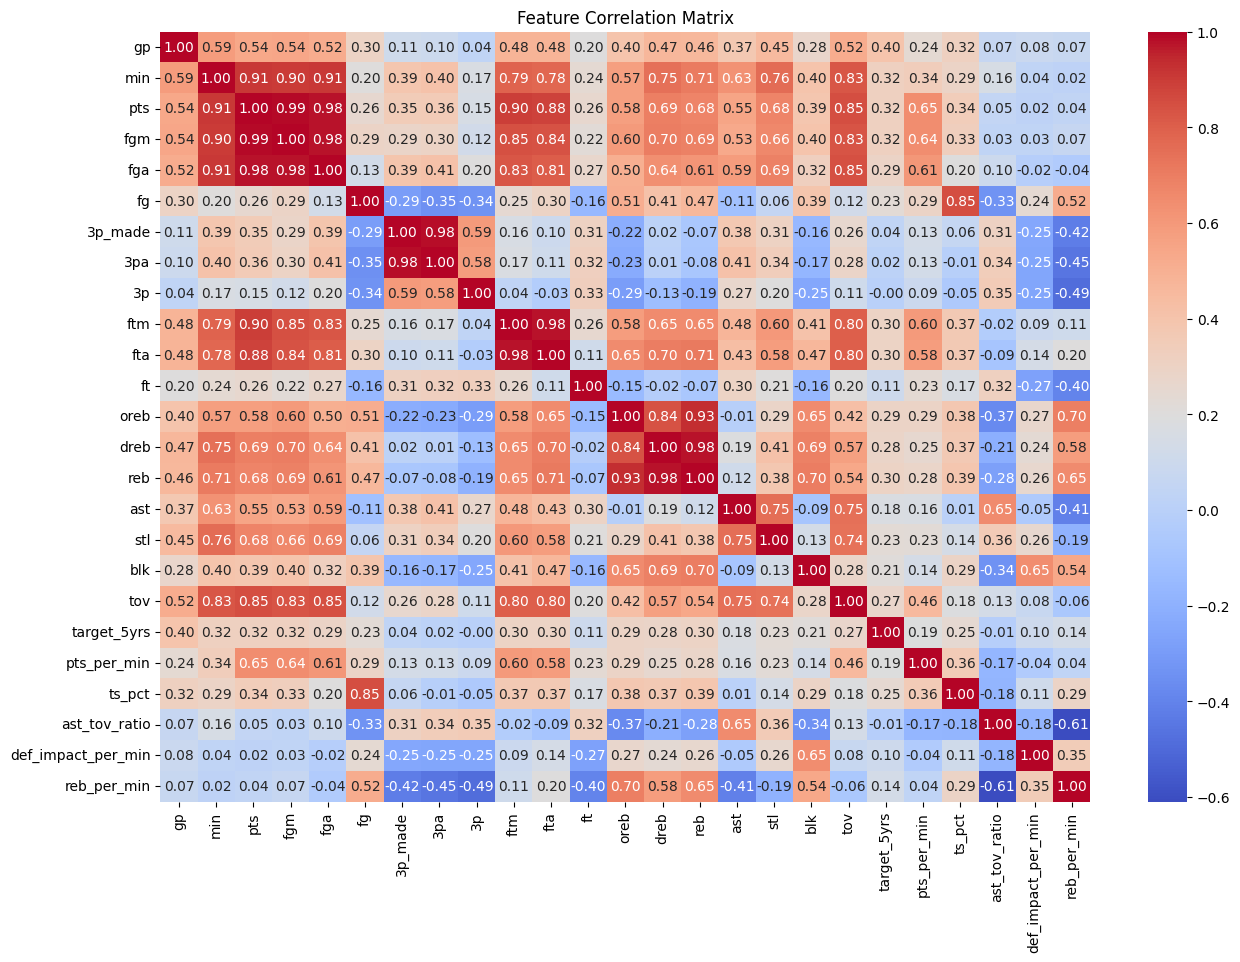

Correlation with Target (target_5yrs):
target_5yrs           1.000000
gp                    0.396833
min                   0.317805
fgm                   0.317594
pts                   0.315981
reb                   0.299406
ftm                   0.296841
fta                   0.296089
oreb                  0.293307
fga                   0.292660
dreb                  0.284677
tov                   0.272348
ts_pct                0.248157
stl                   0.229811
fg                    0.227134
blk                   0.210114
pts_per_min           0.194487
ast                   0.175353
reb_per_min           0.137115
ft                    0.106706
def_impact_per_min    0.101402
3p_made               0.036619
3pa                   0.018110
3p                   -0.000004
ast_tov_ratio        -0.013479
Name: target_5yrs, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
correlation_matrix = df_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Identify features highly correlated with the target
target_corr = correlation_matrix['target_5yrs'].sort_values(ascending=False)
print("Correlation with Target (target_5yrs):")
print(target_corr)